In [106]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# matplotlib globals
plt.rc('font',   size=12)          # controls default text sizes
plt.rc('axes',   titlesize=14)     # fontsize of the axes title
plt.rc('axes',   labelsize=14)     # fontsize of the x and y labels
plt.rc('xtick',  labelsize=14)     # fontsize of the tick labels
plt.rc('ytick',  labelsize=14)     # fontsize of the tick labels
plt.rc('legend', fontsize=14)      # legend fontsize
plt.rc('figure', titlesize=14)     # fontsize of the figure title

data = pd.read_csv('r_phi_bound_geodesic.txt', sep=' ', header=None)
data.head()

,0,1
0,3.0,0.03
1,3.0,0.06
2,3.0,0.09
3,3.0,0.12
4,3.0,0.15


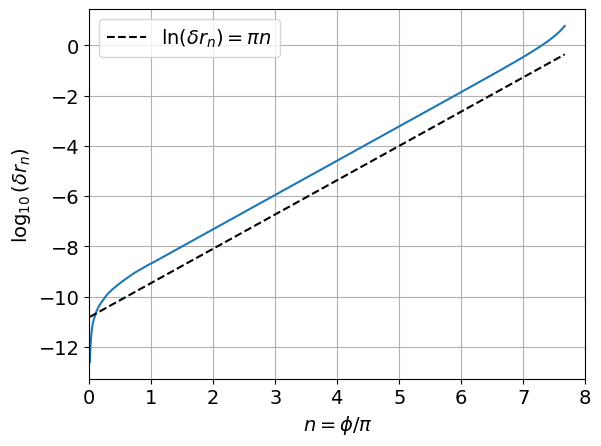

In [107]:
plt.plot(data[1] / np.pi, np.log10(data[0] - 3.))
plt.plot(data[1] / np.pi, (1/np.log(10)) * np.pi* (data[1] / np.pi - 5.) - 4, 'k--', label=r'$\ln(\delta r_n) = \pi n $')
plt.grid()
plt.xlim([0, 8])
plt.ylabel(r'$\log_{10}(\delta r_n)$')
plt.xlabel(r'$n = \phi/\pi$')
plt.legend()
# plt.ylim([np.log10(3.)-1e-5, np.log10(3.)+1e-5])
plt.show()

In [108]:
data2 = pd.read_csv('../../build/FOORT/test/rk4_einstein_ring.dat', sep=' ', header=None)
data2.head()

,0,1,2
0,0.022628,19.980265,0.000265
1,0.045258,19.960531,0.000530
2,0.067893,19.940797,0.000796
3,0.090530,19.921064,0.001062
4,0.113171,19.901331,0.001329


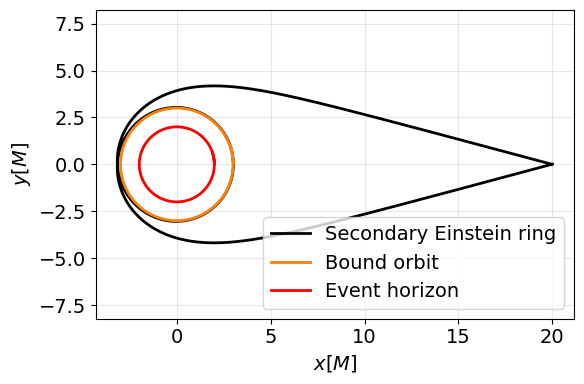

In [112]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.plot(data2[1] * np.cos(data2[2]), data2[1] * np.sin(data2[2]), label = "Secondary Einstein ring", linewidth=2, color = "k")
ax.plot(data[0][:220]*np.cos(data[1][:220]), data[0][:220]*np.sin(data[1][:220]), label = "Bound orbit", linewidth=2, color = "tab:orange")
ax.plot(2*data[0][:220]*np.cos(data[1][:220])/3, 2*data[0][:220]*np.sin(data[1][:220])/3, label = "Event horizon", linewidth=2, color = "red")
ax.grid(color = 'gainsboro', alpha = 0.7)
ax.set_xlabel(r'$x [M]$')
ax.set_ylabel(r'$y [M]$')
ax.legend()
ax.axis('equal')
plt.tight_layout()
fig.savefig('geodesics.png', dpi=300)
plt.show()

In [110]:
results_rk4 = np.array([[0.05, 0.0223723, 931], [0.03, 0.0367611, 1552], [0.01, 0.0104898, 4654], [0.005, 0.0103959, 9308], [0.02, 0.0104711, 23270], [0.001, 0.00981276, 46593]])
results_verlet = np.array([[0.02, 7.0913568093141697, 2345], [0.01, 1.5755, 4662], [0.005, 0.391419, 9312], [0.002, 0.0703238, 23271], [0.001, 0.0250347, 46540]])

/var/folders/vq/_ms1s9j51m14tjk2yqc9vpbh0000gn/T/ipykernel_7600/3685498864.py:13: RuntimeWarning: divide by zero encountered in divide
  secac_x = ax.secondary_xaxis('top', functions=(lambda x: 0.05*931/x, lambda x: 931*0.05/x))


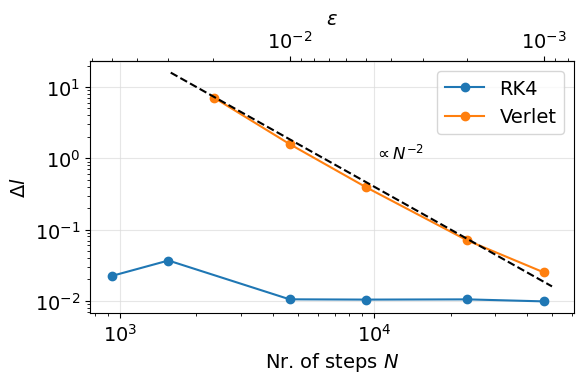

In [113]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(results_rk4[:,2], results_rk4[:,1], 'o-', label='RK4')
ax.plot(results_verlet[:,2], results_verlet[:,1], 'o-', label='Verlet')
x = np.logspace(3.2, 4.7, 100)
ax.plot(x, 4e7/(x*x), 'k--')
ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(color = 'gainsboro', alpha = 0.7)
ax.set_ylabel(r'$\Delta l$')
ax.set_xlabel(r'Nr. of steps $N$')
ax.text(1e4, 1, r'$\propto N^{-2}$', fontsize=12)
ax.legend()
secac_x = ax.secondary_xaxis('top', functions=(lambda x: 0.05*931/x, lambda x: 931*0.05/x))
secac_x.set_xlabel(r'$\epsilon$')
plt.tight_layout()
fig.savefig('convergence.png', dpi=300)
plt.show()